# 07_LSTM_AE_Threshold — 임계값 설정 분석

LSTM Autoencoder의 재구성 오차(MSE)를 이용해 **어느 threshold가 적합한지** 다양한 전략으로 비교.

| 전략 | 방식 | 특징 |
|---|---|---|
| 통계적 (μ+kσ) | val 정상 오차의 평균+k×표준편차 | 정상 분포 가정 |
| 백분위수 | val 정상 오차의 상위 p% | 분포 무가정 |
| F1 최대화 | val F1이 최대인 threshold | 정밀도·재현율 균형 |
| Youden's J | val (TPR-FPR)이 최대인 threshold | ROC 기준 최적점 |
| Recall 목표 | val recall ≥ 목표치를 만족하는 최소 threshold | 이상 미탐 최소화 우선 |

In [7]:
from pathlib import Path

BASE_DIR  = Path.home() / 'Desktop' / 'ai1' / 'original_INC_202501'
MODEL_DIR = Path.home() / 'Desktop' / 'ai1' / 'lstmae_model'   # 06에서 저장된 모델 재사용
MODEL_DIR.mkdir(exist_ok=True)

WINDOW_SIZE = 30
STEP_SIZE   = 10
FEATURES    = ['Avg Voltage', 'Avg Current']

NORMAL_TEST_IDS   = {1,2,3,4,5,7,8,9,10,11,12,28,29,30,44}
ABNORMAL_TEST_IDS = {6,31,45} | set(range(32,44))
NORMAL_VAL_IDS    = set(range(3,10))
ABNORMAL_VAL_IDS  = {1,2}
VAL_TRIAL_IDS     = {44,45}

ENC_HIDDEN = 32
LATENT     = 16
EPOCHS     = 200
BATCH_SIZE = 32
LR         = 1e-3
PATIENCE   = 20
SEED       = 42

RECALL_TARGET = 0.9   # ★ Recall 목표치 (이상 미탐 허용 한도)

print('설정 완료')

설정 완료


In [8]:
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                              roc_curve, precision_recall_curve,
                              f1_score, recall_score, precision_score,
                              average_precision_score)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [9]:
# ── 데이터 로드 (06과 동일) ───────────────────────────────────────

def parse_folder_id(name):
    m = re.match(r'^(Test|Val)(\d+)_', name, flags=re.IGNORECASE)
    return (m.group(1).capitalize(), int(m.group(2))) if m else (None, None)

def get_label(prefix, idx):
    if prefix == 'Test':
        if idx in NORMAL_TEST_IDS:   return 0
        if idx in ABNORMAL_TEST_IDS: return 1
    elif prefix == 'Val':
        if idx in NORMAL_VAL_IDS:    return 0
        if idx in ABNORMAL_VAL_IDS:  return 1
    raise ValueError()

def get_split(prefix, idx):
    if prefix == 'Val':               return 'test'
    if prefix == 'Test':
        if idx in VAL_TRIAL_IDS:     return 'val'
        return 'train'
    raise ValueError()

def engineer(data_norm):
    V = data_norm[:,0:1]; I = data_norm[:,1:2]
    return np.hstack([V, I,
                      np.diff(V, axis=0, prepend=V[[0]]),
                      np.diff(I, axis=0, prepend=I[[0]]),
                      V * I])

records = []
for d in sorted(BASE_DIR.iterdir()):
    if not d.is_dir(): continue
    prefix, idx = parse_folder_id(d.name)
    if prefix is None: continue
    try: label = get_label(prefix, idx); split = get_split(prefix, idx)
    except: continue
    csvs = list(d.glob('*.csv'))
    if not csvs: continue
    data = pd.read_csv(csvs[0])[FEATURES].astype(float).values
    m, s = data.mean(0), data.std(0); s[s < 1e-8] = 1e-8
    records.append({'folder': d.name, 'label': label, 'split': split,
                    'data': engineer((data - m) / s)})

def make_windows(data, ws, ss):
    return np.stack([data[s:s+ws] for s in range(0, len(data)-ws+1, ss)])

buckets = {'train': ([], []), 'val': ([], []), 'test': ([], [])}
test_folders = []
for r in records:
    w  = make_windows(r['data'], WINDOW_SIZE, STEP_SIZE)
    lb = np.full(len(w), r['label'], dtype=np.float32)
    buckets[r['split']][0].append(w)
    buckets[r['split']][1].append(lb)
    if r['split'] == 'test': test_folders.extend([r['folder']] * len(w))

X = {s: np.vstack(buckets[s][0]).astype(np.float32) for s in buckets}
y = {s: np.concatenate(buckets[s][1])               for s in buckets}
test_folders = np.array(test_folders)

n_feat      = X['train'].shape[2]
normal_mask = y['train'] == 0
scaler      = StandardScaler()
scaler.fit(X['train'][normal_mask].reshape(-1, n_feat))

def scale(a):
    n, w, f = a.shape
    return scaler.transform(a.reshape(-1, f)).reshape(n, w, f).astype(np.float32)

Xs = {s: scale(X[s]) for s in X}
Xs_normal = Xs['train'][normal_mask]

for s in ('train', 'val', 'test'):
    u, c = np.unique(y[s], return_counts=True); cnt = dict(zip(u.astype(int), c))
    print(f'{s:5s}  total={len(y[s]):4d}  normal={cnt.get(0,0):4d}  abnormal={cnt.get(1,0):4d}')

train  total= 364  normal= 183  abnormal= 181
val    total=  58  normal=  29  abnormal=  29
test   total= 150  normal=  95  abnormal=  55


In [10]:
# ── 모델 정의 + 로드(없으면 학습) ────────────────────────────────

class LSTMAutoencoder(nn.Module):
    def __init__(self, n_feat, enc_hidden, latent):
        super().__init__()
        self.encoder    = nn.LSTM(n_feat, enc_hidden, batch_first=True)
        self.enc_to_lat = nn.Linear(enc_hidden, latent)
        self.lat_to_dec = nn.Linear(latent, enc_hidden)
        self.decoder    = nn.LSTM(enc_hidden, n_feat, batch_first=True)

    def forward(self, x):
        _, (h, _) = self.encoder(x)
        latent    = self.enc_to_lat(h[-1])
        dec_in    = self.lat_to_dec(latent).unsqueeze(1).expand(-1, x.size(1), -1)
        recon, _  = self.decoder(dec_in)
        return recon

class SeqDS(Dataset):
    def __init__(self, X): self.X = torch.from_numpy(X)
    def __len__(self):      return len(self.X)
    def __getitem__(self, i): return self.X[i]

class LabelDS(Dataset):
    def __init__(self, X, y): self.X = torch.from_numpy(X); self.y = torch.from_numpy(y)
    def __len__(self):         return len(self.y)
    def __getitem__(self, i):  return self.X[i], self.y[i]


model      = LSTMAutoencoder(n_feat, ENC_HIDDEN, LATENT).to(DEVICE)
model_path = MODEL_DIR / 'best_ae.pt'

if model_path.exists():
    model.load_state_dict(torch.load(str(model_path), map_location=DEVICE))
    print(f'저장된 모델 로드: {model_path}')
else:
    print('저장된 모델 없음 → 학습 시작')
    mse   = nn.MSELoss()
    optim = torch.optim.Adam(model.parameters(), lr=LR)
    trl   = DataLoader(SeqDS(Xs_normal), BATCH_SIZE, shuffle=True)
    vll   = DataLoader(LabelDS(Xs['val'], y['val']), BATCH_SIZE)
    best_vl = float('inf'); pc = 0
    for ep in range(1, EPOCHS + 1):
        model.train(); tl = 0; tn = 0
        for Xb in trl:
            Xb = Xb.to(DEVICE); optim.zero_grad()
            loss = mse(model(Xb), Xb)
            loss.backward(); optim.step()
            tl += loss.item() * len(Xb); tn += len(Xb)
        model.eval()
        vl_errs = []
        with torch.no_grad():
            for Xb, _ in vll:
                vl_errs.append(((Xb.to(DEVICE) - model(Xb.to(DEVICE)))**2).mean(dim=(1,2)).cpu().numpy())
        vl = np.concatenate(vl_errs).mean()
        if ep % 20 == 0 or ep == 1: print(f'Ep {ep:3d}  train={tl/tn:.4f}  val={vl:.4f}')
        if vl < best_vl: best_vl = vl; pc = 0; torch.save(model.state_dict(), str(model_path))
        else:
            pc += 1
            if pc >= PATIENCE: print(f'EarlyStop ep={ep}'); break
    model.load_state_dict(torch.load(str(model_path), map_location=DEVICE))
    print(f'학습 완료')

저장된 모델 로드: C:\Users\ehdrmsdua\Desktop\ai1\lstmae_model\best_ae.pt


In [11]:
# ── 재구성 오차 계산 ──────────────────────────────────────────────

def get_errors(windows):
    model.eval()
    loader = DataLoader(SeqDS(windows), BATCH_SIZE)
    errs = []
    with torch.no_grad():
        for Xb in loader:
            e = ((Xb.to(DEVICE) - model(Xb.to(DEVICE))) ** 2).mean(dim=(1,2))
            errs.append(e.cpu().numpy())
    return np.concatenate(errs)

val_err  = get_errors(Xs['val'])
test_err = get_errors(Xs['test'])

val_true  = y['val'].astype(int)
test_true = y['test'].astype(int)

val_normal_err   = val_err[val_true == 0]
val_abnormal_err = val_err[val_true == 1]

print(f'Val  정상 오차: μ={val_normal_err.mean():.4f}  σ={val_normal_err.std():.4f}'  
      f'  min={val_normal_err.min():.4f}  max={val_normal_err.max():.4f}')
print(f'Val  이상 오차: μ={val_abnormal_err.mean():.4f}  σ={val_abnormal_err.std():.4f}'
      f'  min={val_abnormal_err.min():.4f}  max={val_abnormal_err.max():.4f}')

Val  정상 오차: μ=0.3483  σ=0.4360  min=0.0444  max=1.8964
Val  이상 오차: μ=0.5670  σ=0.7703  min=0.0401  max=4.4726


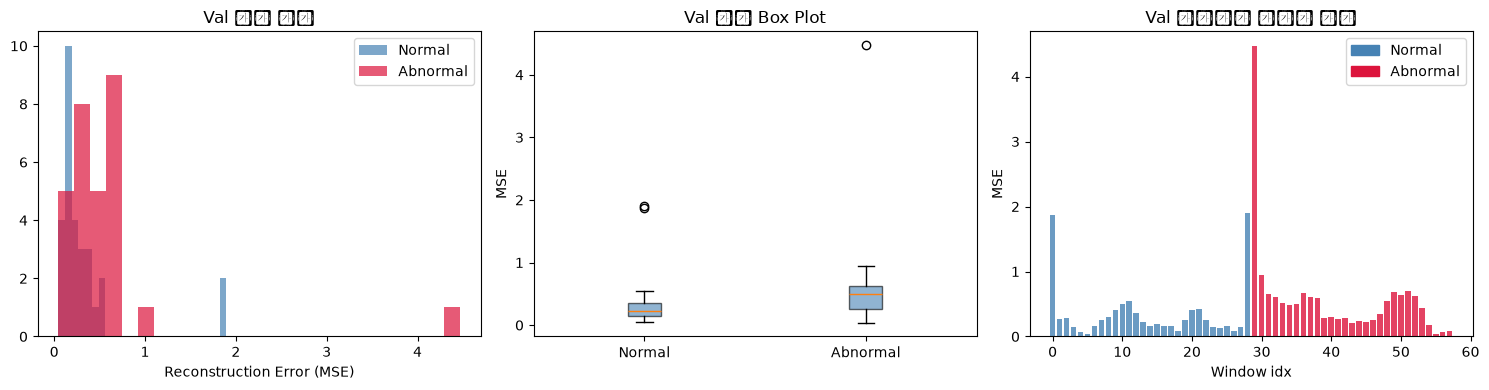

In [12]:
# ── Val 오차 분포 시각화 ──────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) 오차 분포 히스토그램
axes[0].hist(val_normal_err,   bins=25, alpha=0.7, color='steelblue', label='Normal')
axes[0].hist(val_abnormal_err, bins=25, alpha=0.7, color='crimson',   label='Abnormal')
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_title('Val 오차 분포'); axes[0].legend()

# 2) Box plot (tick_labels: matplotlib>=3.9, 하위호환 fallback 포함)
bp = axes[1].boxplot([val_normal_err, val_abnormal_err],
                     patch_artist=True,
                     boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Normal', 'Abnormal'])
axes[1].set_ylabel('MSE'); axes[1].set_title('Val 오차 Box Plot')

# 3) 윈도우별 오차 (시간 순서)
colors = ['steelblue' if l == 0 else 'crimson' for l in val_true]
axes[2].bar(range(len(val_err)), val_err, color=colors, alpha=0.8)
axes[2].set_xlabel('Window idx'); axes[2].set_ylabel('MSE')
axes[2].set_title('Val 윈도우별 재구성 오차')
axes[2].legend(handles=[
    mpatches.Patch(color='steelblue', label='Normal'),
    mpatches.Patch(color='crimson',   label='Abnormal')
])

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'th_val_dist.png'), dpi=150)
plt.show()

In [13]:
# ── Threshold 전략 정의 ───────────────────────────────────────────

mu  = val_normal_err.mean()
sig = val_normal_err.std()

strategies = {}

# 1) 통계적: μ + k*σ
for k in [1, 2, 3]:
    strategies[f'μ+{k}σ'] = mu + k * sig

# 2) 백분위수: val 정상 오차의 상위 p%
for p in [90, 95, 99]:
    strategies[f'Pct-{p}'] = np.percentile(val_normal_err, p)

# 3) F1 최대화
best_f1, best_t_f1 = 0, 0
for t in np.linspace(val_err.min(), val_err.max(), 300):
    f = f1_score(val_true, (val_err >= t).astype(int), zero_division=0)
    if f > best_f1: best_f1 = f; best_t_f1 = t
strategies['F1-max'] = best_t_f1

# 4) Youden's J: TPR - FPR 최대
fpr_v, tpr_v, th_v = roc_curve(val_true, val_err)
j_idx = np.argmax(tpr_v - fpr_v)
strategies["Youden's J"] = th_v[j_idx]

# 5) Recall 목표 (RECALL_TARGET 이상 만족하는 최소 threshold)
best_t_rec = val_err.max()   # 기본값: 아무것도 이상으로 안 잡음
for t in np.linspace(val_err.max(), val_err.min(), 300):
    rec = recall_score(val_true, (val_err >= t).astype(int), zero_division=0)
    if rec >= RECALL_TARGET:
        best_t_rec = t
        break
strategies[f'Recall≥{RECALL_TARGET}'] = best_t_rec

print(f'=== Threshold 후보 (val 정상 μ={mu:.4f}, σ={sig:.4f}) ===')
for name, t in strategies.items():
    pred = (val_err >= t).astype(int)
    rec  = recall_score(val_true, pred, zero_division=0)
    pre  = precision_score(val_true, pred, zero_division=0)
    f1   = f1_score(val_true, pred, zero_division=0)
    print(f'  {name:18s}  threshold={t:.4f}  precision={pre:.3f}  recall={rec:.3f}  F1={f1:.3f}')

=== Threshold 후보 (val 정상 μ=0.3483, σ=0.4360) ===
  μ+1σ                threshold=0.7844  precision=0.500  recall=0.069  F1=0.121
  μ+2σ                threshold=1.2204  precision=0.333  recall=0.034  F1=0.062
  μ+3σ                threshold=1.6564  precision=0.333  recall=0.034  F1=0.062
  Pct-90              threshold=0.5113  precision=0.812  recall=0.448  F1=0.578
  Pct-95              threshold=1.3384  precision=0.333  recall=0.034  F1=0.062
  Pct-99              threshold=1.8882  precision=0.500  recall=0.034  F1=0.065
  F1-max              threshold=0.2032  precision=0.625  recall=0.862  F1=0.725
  Youden's J          threshold=0.4352  precision=0.800  recall=0.552  F1=0.653
  Recall≥0.9          threshold=0.0698  precision=0.509  recall=0.966  F1=0.667


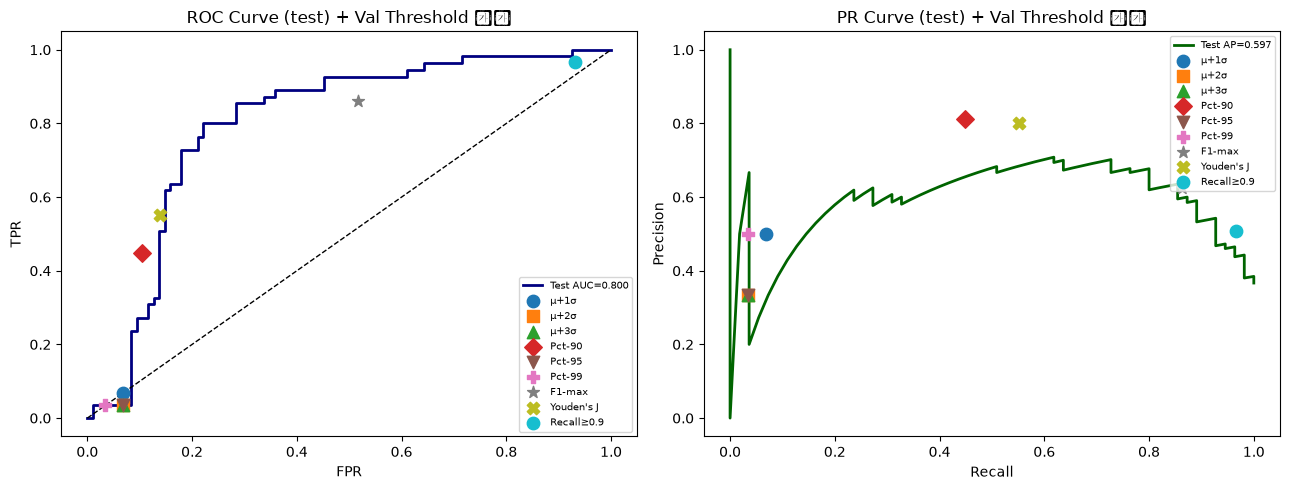


Test ROC-AUC: 0.7998
Test PR-AUC (Average Precision): 0.5966


In [14]:
# ── ROC / PR 곡선 + Threshold 위치 표시 ──────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
fpr_t, tpr_t, _ = roc_curve(test_true, test_err)
auc_roc = roc_auc_score(test_true, test_err)
axes[0].plot(fpr_t, tpr_t, lw=2, color='navy', label=f'Test AUC={auc_roc:.3f}')
axes[0].plot([0,1],[0,1],'k--',lw=1)

# Val ROC에 각 threshold 점 표시
marker_styles = ['o','s','^','D','v','P','*','X']
colors_map    = plt.cm.tab10(np.linspace(0, 1, len(strategies)))
for i, (name, t) in enumerate(strategies.items()):
    pred = (val_err >= t).astype(int)
    rec  = recall_score(val_true, pred, zero_division=0)
    fp   = ((pred == 1) & (val_true == 0)).sum() / max((val_true == 0).sum(), 1)
    axes[0].scatter(fp, rec, marker=marker_styles[i % len(marker_styles)],
                    color=colors_map[i], s=80, zorder=5, label=name)

axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve (test) + Val Threshold 위치')
axes[0].legend(fontsize=7, loc='lower right')

# PR 곡선
pre_t, rec_t, _ = precision_recall_curve(test_true, test_err)
auc_pr = average_precision_score(test_true, test_err)
axes[1].plot(rec_t, pre_t, lw=2, color='darkgreen', label=f'Test AP={auc_pr:.3f}')

for i, (name, t) in enumerate(strategies.items()):
    pred = (val_err >= t).astype(int)
    rec  = recall_score(val_true, pred, zero_division=0)
    pre  = precision_score(val_true, pred, zero_division=0)
    axes[1].scatter(rec, pre, marker=marker_styles[i % len(marker_styles)],
                    color=colors_map[i], s=80, zorder=5, label=name)

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve (test) + Val Threshold 위치')
axes[1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'th_curves.png'), dpi=150)
plt.show()

print(f'\nTest ROC-AUC: {auc_roc:.4f}')
print(f'Test PR-AUC (Average Precision): {auc_pr:.4f}')

In [15]:
# ── Test 결과 비교표 ──────────────────────────────────────────────

rows = []
for name, t in strategies.items():
    pred = (test_err >= t).astype(int)
    rec  = recall_score(test_true, pred, zero_division=0)
    pre  = precision_score(test_true, pred, zero_division=0)
    f1   = f1_score(test_true, pred, zero_division=0)
    acc  = (pred == test_true).mean()

    # Trial-level
    trial_correct = 0; n_trials = 0
    for folder in sorted(set(test_folders)):
        mask   = test_folders == folder
        mean_e = test_err[mask].mean()
        true_l = int(test_true[mask][0])
        pred_l = 1 if mean_e >= t else 0
        trial_correct += (pred_l == true_l)
        n_trials += 1

    rows.append({
        'Strategy':      name,
        'Threshold':     round(t, 4),
        'Precision':     round(pre, 3),
        'Recall':        round(rec, 3),
        'F1':            round(f1, 3),
        'Win Acc':       round(acc, 3),
        'Trial Acc':     f'{trial_correct}/{n_trials}',
    })

df_result = pd.DataFrame(rows)
print('=== Test 평가 비교표 ===')
print(df_result.to_string(index=False))

=== Test 평가 비교표 ===
  Strategy  Threshold  Precision  Recall    F1  Win Acc Trial Acc
      μ+1σ     0.7844      0.333   0.036 0.066    0.620       3/5
      μ+2σ     1.2204      0.400   0.036 0.067    0.627       2/5
      μ+3σ     1.6564      0.500   0.036 0.068    0.633       3/5
    Pct-90     0.5113      0.200   0.036 0.062    0.593       3/5
    Pct-95     1.3384      0.500   0.036 0.068    0.633       2/5
    Pct-99     1.8882      0.500   0.036 0.068    0.633       3/5
    F1-max     0.2032      0.579   0.200 0.297    0.653       4/5
Youden's J     0.4352      0.200   0.036 0.062    0.593       3/5
Recall≥0.9     0.0698      0.696   0.582 0.634    0.753       2/5


In [16]:
# ── Trial-level 상세 결과 (전략별) ───────────────────────────────

trial_folders = sorted(set(test_folders))
trial_true    = [int(test_true[test_folders == f][0]) for f in trial_folders]
trial_scores  = [test_err[test_folders == f].mean()   for f in trial_folders]

print(f'\n{"Trial":35s}  {"True":5s}  {"Score":7s}  ', end='')
for name in strategies: print(f'{name[:8]:>9s}', end='')
print()
print('-' * (55 + 9 * len(strategies)))

for folder, true_l, score in zip(trial_folders, trial_true, trial_scores):
    short = folder[:35]
    print(f'{short:35s}  {true_l:5d}  {score:7.4f}  ', end='')
    for name, t in strategies.items():
        pred_l = 1 if score >= t else 0
        ok     = 'O' if pred_l == true_l else 'X'
        print(f'{ok:>9s}', end='')
    print()


Trial                                True   Score         μ+1σ     μ+2σ     μ+3σ   Pct-90   Pct-95   Pct-99   F1-max Youden's Recall≥0
----------------------------------------------------------------------------------------------------------------------------------------
Val1_130A_22TS_170WFR                    1   0.9250          O        X        X        O        X        X        O        O        O
Val2_130A_24TS_200WFR                    1   0.2827          X        X        X        X        X        X        O        X        O
Val5_217A_22TS_170WFR                    0   1.5843          X        X        O        X        X        O        X        X        X
Val8_237A_22TS_200WFR                    0   0.0889          O        O        O        O        O        O        O        O        X
Val9_237A_24TS_170WFR                    0   0.1711          O        O        O        O        O        O        O        O        X


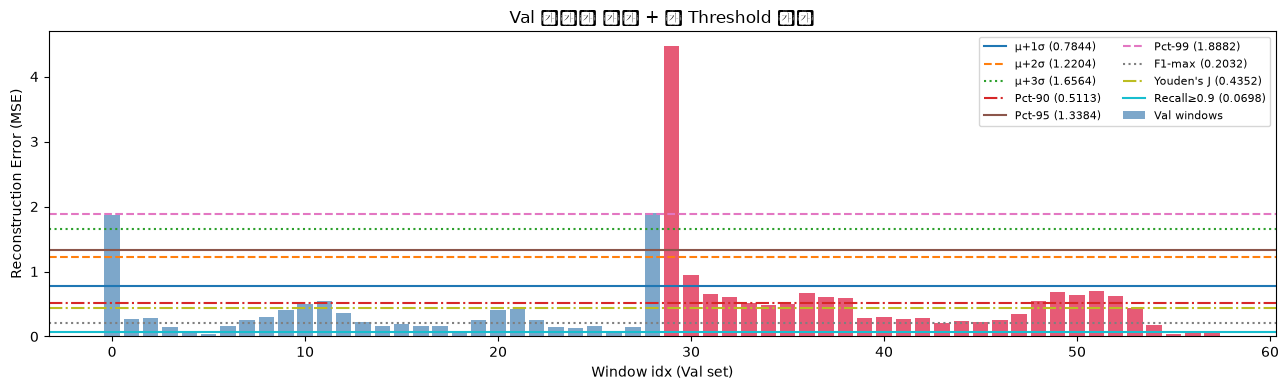

In [17]:
# ── Threshold 시각화 (val 정상 오차 기준선 + 각 전략) ─────────────

fig, ax = plt.subplots(figsize=(13, 4))

colors_t = ['steelblue' if l == 0 else 'crimson' for l in val_true]
ax.bar(range(len(val_err)), val_err, color=colors_t, alpha=0.7, label='Val windows')

line_styles = ['-', '--', ':', '-.', '-', '--', ':', '-.']
for i, (name, t) in enumerate(strategies.items()):
    ax.axhline(t, linestyle=line_styles[i % len(line_styles)],
               color=colors_map[i], lw=1.5, label=f'{name} ({t:.4f})')

ax.set_xlabel('Window idx (Val set)')
ax.set_ylabel('Reconstruction Error (MSE)')
ax.set_title('Val 재구성 오차 + 각 Threshold 전략')
ax.legend(fontsize=8, loc='upper right', ncol=2)

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'th_comparison.png'), dpi=150)
plt.show()